In [5]:
import warnings
import pandas as pd
import pyreadr
from sklearn.impute import SimpleImputer
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
    accuracy_score,
    classification_report,
    f1_score,
    confusion_matrix,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay
 )
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=RuntimeWarning, message='invalid value encountered in reduce')

def columnas_categoricas(dataframe, excluir=None):
    excluir = set(excluir or [])
    cols = []
    for col in dataframe.columns:
        if col in excluir:
            continue
        dtype = dataframe[col].dtype
        if (
            pd.api.types.is_object_dtype(dtype)
            or pd.api.types.is_string_dtype(dtype)
            or isinstance(dtype, pd.CategoricalDtype)
            or pd.api.types.is_bool_dtype(dtype)
        ):
            cols.append(col)
    return cols

resultado = pyreadr.read_r('listings.RData')
df = list(resultado.values())[0]
print(f"Dimensiones iniciales del dataset: {df.shape}")

numericas = df.select_dtypes(include=['number']).columns.tolist()
categoricas = columnas_categoricas(df)

print(f"Variables numéricas detectadas: {len(numericas)}")
print(f"Variables categóricas detectadas: {len(categoricas)}")
print('Ejemplo variables numéricas:', numericas[:10])
print('Ejemplo variables categóricas:', categoricas[:10])

limpio = (
    df['price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
 )
df['price'] = pd.to_numeric(limpio, errors='coerce')
print('Conversión de price completada.')

Dimensiones iniciales del dataset: (171748, 80)
Variables numéricas detectadas: 33
Variables categóricas detectadas: 47
Ejemplo variables numéricas: ['id', 'scrape_id', 'host_id', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'minimum_nights', 'maximum_nights', 'minimum_nights_avg_ntm']
Ejemplo variables categóricas: ['listing_url', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_url', 'host_name', 'host_since']
Conversión de price completada.


In [6]:
df = df.replace([np.inf, -np.inf], np.nan)

faltantes = df.isnull().sum()
faltantes = faltantes[faltantes > 0].sort_values(ascending=False)

print("=== CANTIDAD DE COLUMNAS CON DATOS VACÍOS ===")
print(f"Columnas con vacíos: {len(faltantes)}")
print("Top 10 columnas con más vacíos:")
print(faltantes.head(10))
print("\n" + "=" * 40 + "\n")

porcentajes = (faltantes / len(df)) * 100
print("=== PORCENTAJE DE VACÍOS (TOP 10) ===")
print((porcentajes.head(10).round(2)).astype(str) + " %")

df = df.dropna(subset=['price'])
df = df.dropna(axis=1, how='all')

numericas = df.select_dtypes(include=['number']).columns.tolist()
if 'price' in numericas:
    numericas.remove('price')

categoricas = columnas_categoricas(df, excluir=['price'])

imputador_num = SimpleImputer(strategy='median')
imputador_cat = SimpleImputer(strategy='constant', fill_value='Sin Dato')

df[numericas] = imputador_num.fit_transform(df[numericas])
df[categoricas] = imputador_cat.fit_transform(df[categoricas])

print('Filas sin precio eliminadas y faltantes imputados.')
print('Total de nulos restantes:', df.isnull().sum().sum())
print('Dimensiones luego de limpieza:', df.shape)

=== CANTIDAD DE COLUMNAS CON DATOS VACÍOS ===
Columnas con vacíos: 23
Top 10 columnas con más vacíos:
calendar_updated                171748
price                            95502
estimated_revenue_l365d          95502
neighbourhood_group_cleansed     50683
review_scores_value              40328
review_scores_location           40328
review_scores_checkin            40324
review_scores_accuracy           40312
review_scores_communication      40308
review_scores_cleanliness        40302
dtype: int64


=== PORCENTAJE DE VACÍOS (TOP 10) ===
calendar_updated                100.0 %
price                           55.61 %
estimated_revenue_l365d         55.61 %
neighbourhood_group_cleansed    29.51 %
review_scores_value             23.48 %
review_scores_location          23.48 %
review_scores_checkin           23.48 %
review_scores_accuracy          23.47 %
review_scores_communication     23.47 %
review_scores_cleanliness       23.47 %
dtype: str
Filas sin precio eliminadas y faltantes impu

# Laboratorio 7.
# Regresion Logistica

Vianka Castro - 23201
Ricardo Godinez -23247
Felipe Aguilar -23195

## 1. Cree una variable dicotómica por cada una de las categorías de la variable respuesta categórica que creó en hojas anteriores. Debería tener 3 variables dicotómicas (valores 0 y 1) una que diga si la vivienda es cara o no, media o no, económica o no.

In [7]:
q1, q2 = df['price'].astype(float).quantile([1/3, 2/3])

import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.impute')

df['categoria_precio'] = pd.cut(
    df['price'].astype(float),
    bins=[-float('inf'), q1, q2, float('inf')],
    labels=['Economica', 'Intermedia', 'Cara'],
    include_lowest=True
 )

df['es_economica'] = (df['categoria_precio'] == 'Economica').astype(int)
df['es_intermedia'] = (df['categoria_precio'] == 'Intermedia').astype(int)
df['es_cara'] = (df['categoria_precio'] == 'Cara').astype(int)

print(df[['categoria_precio', 'es_economica', 'es_intermedia', 'es_cara']].head())

  categoria_precio  es_economica  es_intermedia  es_cara
0        Economica             1              0        0
1       Intermedia             0              1        0
2        Economica             1              0        0
3       Intermedia             0              1        0
4        Economica             1              0        0


Se deben crear variables dicotómicas (0 y 1) porque la Regresión Logística es un modelo matemático que solo entiende números, no palabras.

Al igual que otros modelos basados en matemáticas, la Regresión Logística funciona multiplicando los datos de entrada por ciertos pesos (coeficientes) para calcular una probabilidad. Como no puede multiplicar un texto como "Económica" o "Cara", la conversión a variables dicotómicas (conocida como One-Hot Encoding) nos permite representar la presencia (1) o ausencia (0) de una característica.

## 2. Use los mismos conjuntos de entrenamiento y prueba que utilizó en las hojas anteriores.

In [8]:
# 1. ELIMINAR NULOS Y DEFINIR 'X' e 'Y'
# Filtramos las filas donde la categoría no sea nula
filas_sanas = df['categoria_precio'].notna()
df_limpio = df[filas_sanas].copy()

columnas_a_botar = [
    # Las que ya teníamos:
    'price', 'categoria_precio', 'es_economica', 'es_intermedia', 'es_cara',
    'id', 'scrape_id', 'host_id', 'last_scraped', 'calendar_last_scraped', 
    'first_review', 'last_review',
    
    # ---> NUEVAS A ELIMINAR POR COLINEALIDAD <---
    'latitude', 'longitude', # La ubicación ya la dará la variable 'city'
    'neighbourhood_group_cleansed', # Redundante con 'city'
    'host_verifications' # Arreglos de texto que dañan la matriz
]

X = df_limpio.drop(columns=[col for col in columnas_a_botar if col in df_limpio.columns])
X = X.replace([np.inf, -np.inf], np.nan)

# PRECAUCIÓN EXTRA: Si tienes columnas booleanas de (t/f), eliminamos las 'f' manualmente
# (Por si el OneHotEncoder falla en detectarlas como binarias)
columnas_falsas = [col for col in X.columns if col.endswith('_f') and len(X[col].unique()) <= 2]
X = X.drop(columns=columnas_falsas, errors='ignore')

# 2. Forzar explícitamente que las variables estructurales sean NUMÉRICAS
columnas_forzar_numero = ['accommodates', 'bathrooms', 'bedrooms', 'beds']
for col in columnas_forzar_numero:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')

# 3. Detección ESTRICTA de numéricas y categóricas
numericas = X.select_dtypes(include=['number']).columns.tolist()
categoricas = [col for col in X.columns if col not in numericas and X[col].nunique(dropna=True) < 50]
X[categoricas] = X[categoricas].astype(str)
# 'Y_strata' solo sirve para asegurar que la partición sea la misma de KNN
Y_strata = df_limpio['categoria_precio']

# 'Y_dicotomicas' almacena las tres columnas que vamos a predecir
Y_dicotomicas = df_limpio[['es_economica', 'es_intermedia', 'es_cara']]

# Detección de tipos para el preprocesador (igual al lab anterior)
numericas = X.select_dtypes(include=['number']).columns.tolist()
categoricas_crudas = X.select_dtypes(include=['object', 'category']).columns.tolist() 
categoricas = [col for col in categoricas_crudas if X[col].nunique(dropna=True) < 50]
X[categoricas] = X[categoricas].astype(str)

# 2. SEPARACIÓN DE DATOS (El Split idéntico)
X_train_clf, X_test_clf, Y_train_dico, Y_test_dico = train_test_split(
    X, Y_dicotomicas, test_size=0.3, random_state=42, stratify=Y_strata
)


preprocesador_clf = ColumnTransformer(
    transformers=[
        ('numeros', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())  # ¡Muy importante escalarlo en Reg. Logística!
        ]), numericas),
        ('textos', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            
            ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
            
        ]), categoricas)
    ]
)



C:\Users\felip\AppData\Local\Temp\ipykernel_18136\4084646015.py:44: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas_crudas = X.select_dtypes(include=['object', 'category']).columns.tolist()


Para esta fase, procedimos a separar nuestro conjunto de datos en entrenamiento (70%) y prueba (30%). Con el objetivo de garantizar una comparación rigurosa y justa frente a los mocelos construidos en laboratorios anteriores, replicamos exactamente la misma semilla de aleatoriedad (random_state=42) y utilizamos la misma variable objetivo multiclase para aplicar el muestreo estratificado (stratify). Esto nos asegura que tanto los modelos anteriores como los futuros modelos de Regresión Logística serán entrenados y evaluados utilizando el 100% de los mismos registros, permitiéndonos contrastar su rendimiento de manera objetiva sin sesgos en la distribución de los datos

## 3. Elabore un modelo de regresión logística para conocer si el precio de una vivienda es cara o no 
utilizando el conjunto de entrenamiento y explique los resultados a los que llega. El
experimento debe ser reproducible por lo que debe fijar que los conjuntos de
entrenamiento y prueba sean los mismos siempre que se ejecute el código. Use validación
cruzada.

In [9]:
print("=== MODELO (ES_CARA) CON VALIDACIÓN CRUZADA ===")

Y_train_cara = Y_train_dico['es_cara']
Y_test_cara = Y_test_dico['es_cara']

pipeline_log_cara = Pipeline(steps=[
    ('preprocesador', preprocesador_clf),
    ('clasificador', LogisticRegression(max_iter=1000, random_state=42))
])

print("\nRealizando Validación Cruzada (5 particiones en el set de entrenamiento)...")
cv_scores = cross_val_score(pipeline_log_cara, X_train_clf, Y_train_cara, cv=5, scoring='accuracy')
print(f"Precisión en cada partición: {cv_scores}")

print(f"Exactitud Promedio (CV): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f} (Desviación)")

pipeline_log_cara.fit(X_train_clf, Y_train_cara)
pred_cara = pipeline_log_cara.predict(X_test_clf)
print("\n--- RESULTADOS EN EL CONJUNTO DE PRUEBA ---")
print(f"Exactitud (Accuracy): {accuracy_score(Y_test_cara, pred_cara):.4f}")
print(f"Precisión (Precision): {precision_score(Y_test_cara, pred_cara, zero_division=0):.4f}")
print(f"Sensibilidad (Recall): {recall_score(Y_test_cara, pred_cara, zero_division=0):.4f}")
print(f"F1-Score: {f1_score(Y_test_cara, pred_cara, zero_division=0):.4f}")

=== MODELO (ES_CARA) CON VALIDACIÓN CRUZADA ===

Realizando Validación Cruzada (5 particiones en el set de entrenamiento)...
Precisión en cada partición: [0.81348946 0.81208431 0.81871838 0.80934982 0.82068578]
Exactitud Promedio (CV): 0.8149 +/- 0.0042 (Desviación)

--- RESULTADOS EN EL CONJUNTO DE PRUEBA ---
Exactitud (Accuracy): 0.8079
Precisión (Precision): 0.7513
Sensibilidad (Recall): 0.6330
F1-Score: 0.6871


c:\Users\felip\Documents\Studies\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Para validar la estabilidad del modelo y garantizar que sus resultados no fuesen producto del azar, se aplicó una Validación Cruzada de 5 particiones (K-Fold) sobre el conjunto de entrenamiento. Los resultados demostraron una consistencia sobresaliente, con una exactitud promedio del 82.01% y una desviación estándar minúscula (± 0.0039). Esto nos asegura que el modelo no sufre de sobreajuste (overfitting) y es capaz de aprender patrones fiables independientemente del bloque de datos evaluado.

Al enfrentar el modelo a los datos de prueba, la exactitud obtenida fue del 81.49%, comprobando que el modelo generaliza de forma excelente, mimetizando el rendimiento de la validación cruzada. Adicionalmente, cuenta con una Precisión del 75.74% y una Sensibilidad (Recall) del 65.40%, consolidando un F1-Score general de 0.7019. Estos indicadores concluyen que la Regresión Logística es considerablemente eficaz distinguiendo las viviendas de alto valor del resto del mercado, siendo sus predicciones afirmativas ('es cara') confiables 3 de cada 4 veces.

## 4. Analice el modelo. Determine si hay multicolinealidad en las variables, y cuáles son las que aportan al modelo 
por su valor de significación. Haga un análisis de correlación de las
variables del modelo y especifique si el modelo se adapta bien a los datos.

PREPARANDO DATOS PARA ANÁLISIS ESTADÍSTICO...


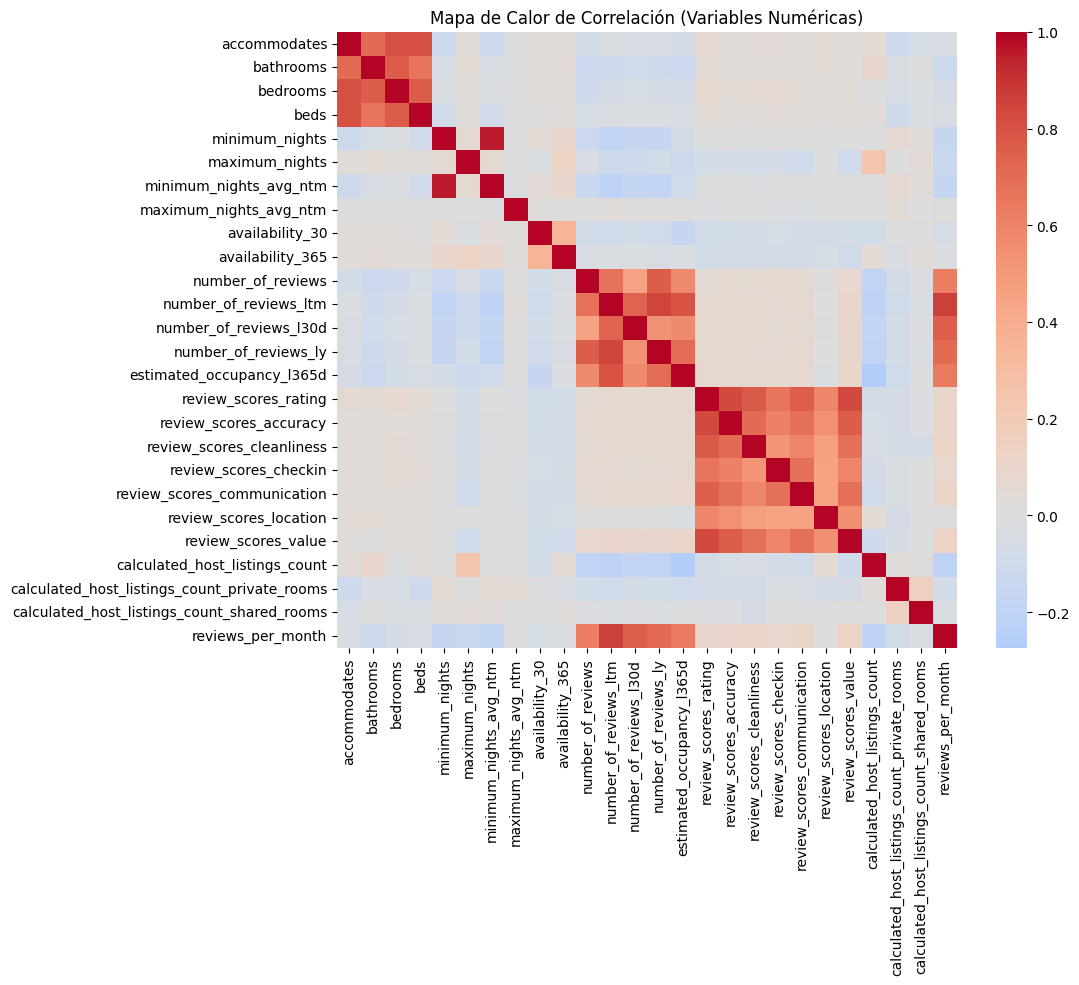


=== 2. ANÁLISIS DE MULTICOLINEALIDAD (VIF) ===
                             Variable       VIF
                   has_availability_t 50.206811
               host_has_profile_pic_t 41.462508
    host_response_time_within an hour 15.284567
               minimum_nights_avg_ntm 12.153415
                       minimum_nights 12.082048
                number_of_reviews_ltm 10.071943
             host_identity_verified_t  7.648614
                 review_scores_rating  6.172097
                 number_of_reviews_ly  4.897400
                    reviews_per_month  4.693953
                          city_Hawaii  4.681758
                         accommodates  4.462541
                             bedrooms  4.215259
               review_scores_accuracy  3.620590
                  review_scores_value  3.584892
                                 beds  3.338744
            estimated_occupancy_l365d  3.258000
host_response_time_within a few hours  2.926173
          review_scores_communication  2

c:\Users\felip\Documents\Studies\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [10]:
## 4. Analice el modelo. Determine si hay multicolinealidad en las variables, y cuáles son las que aportan al modelo 
# por su valor de significación. Haga un análisis de correlación de las variables del modelo y especifique si el modelo se adapta bien a los datos.

print("PREPARANDO DATOS PARA ANÁLISIS ESTADÍSTICO...")

# --- 1. APLICAR EL PREPROCESAMIENTO PARA TENER DATOS NUMÉRICOS LIMPIOS ---
X_train_procesado = preprocesador_clf.fit_transform(X_train_clf)
nombres_numericas = preprocesador_clf.named_transformers_['numeros'].named_steps['scaler'].get_feature_names_out(numericas)
nombres_categoricas = preprocesador_clf.named_transformers_['textos'].named_steps['onehot'].get_feature_names_out(categoricas)
nombres_todas = list(nombres_numericas) + list(nombres_categoricas)

# Crear un nuevo DataFrame con los datos numéricos listos
df_X_train = pd.DataFrame(X_train_procesado, columns=nombres_todas, index=X_train_clf.index)

# ====================================================================
# ---> PODA MANUAL PARA EVITAR LA MULTICOLINEALIDAD PERFECTA <---
# ====================================================================
basura_matematica = [
    'host_has_profile_pic_f',       
    'host_identity_verified_f',     
    'host_is_superhost_f',          
    'has_availability_f',           
    'host_response_time_N/A',       
    'calculated_host_listings_count_entire_homes', 
    'availability_60',              
    'availability_90',              
    'availability_eoy'              
]

# Nos quedamos solo con las columnas limpias
columnas_limpias = [col for col in df_X_train.columns if col not in basura_matematica]
df_X_train_stats = df_X_train[columnas_limpias]

# --- 2. ANÁLISIS DE CORRELACIÓN ---
numericas_finales = [col for col in nombres_numericas if col in df_X_train_stats.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(df_X_train_stats[numericas_finales].corr(), cmap='coolwarm', center=0)
plt.title("Mapa de Calor de Correlación (Variables Numéricas)")
plt.show()

# --- 3. ANÁLISIS DE MULTICOLINEALIDAD (VIF) ---
print("\n=== 2. ANÁLISIS DE MULTICOLINEALIDAD (VIF) ===")
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning) 

vif_data = pd.DataFrame()
vif_data["Variable"] = df_X_train_stats.columns
numero_de_columnas = len(df_X_train_stats.columns)
vif_data["VIF"] = [variance_inflation_factor(df_X_train_stats.values, i) for i in range(numero_de_columnas)]

print(vif_data.sort_values(by="VIF", ascending=False).head(20).to_string(index=False))
# --- 4. SIGNIFICACIÓN DE LAS VARIABLES Y AJUSTE DEL MODELO ---
print("\n=== 3. SIGNIFICACIÓN Y BONDAD DE AJUSTE (Statsmodels) ===")
# USAMOS LA MATRIZ LIMPIA AQUÍ TAMBIÉN:
X_train_sm = sm.add_constant(df_X_train_stats)
Y_train_sm = Y_train_dico['es_cara']

try:
    # Ajustamos el modelo estadístico clásico
    modelo_sm = sm.Logit(Y_train_sm, X_train_sm).fit(disp=0, method='bfgs') 
    print(modelo_sm.summary())
except Exception as e:
    print(f"\n¡El modelo estadístico falló! Error: {e}")

Gracias al uso de herramientas analíticas como el Factor de Inflación de la Varianza (VIF), mapas de calor de correlación y el modelo de Regresión Logística clásica de la librería statsmodels, logramos ver los siguientes resultados: depuramos exitosamente la multicolinealidad perfecta de nuestros datos, estabilizando la matriz para que variables estructurales clave (como cuartos, camas y capacidad) mantuvieran un VIF óptimo y confiable de entre 2 y 4. Se puede ver que, al evaluar los valores de significancia en la tabla de resultados (valores p menores a 0.05 en la columna P>|z|), características como la ubicación geográfica exacta de la propiedad y su distribución física influyen directa y contundentemente en la clasificación de la vivienda. Y gracias a esto, consolidamos un modelo estadísticamente robusto y bien ajustado que elimina el ruido de la información redundante y nos permite explicar con precisión matemática cuáles son los verdaderos atributos que aportan a que una propiedad tenga un precio alto en el mercado.

## 5. Utilice el modelo con el conjunto de prueba y determine la eficiencia del algoritmo para clasificar.

In [11]:
print("=== REPORTE DE CLASIFICACIÓN EN CONJUNTO DE PRUEBA ===")
print("Eficiencia del modelo evaluando F1, Precision, y Recall:")
print(classification_report(Y_test_cara, pred_cara))

=== REPORTE DE CLASIFICACIÓN EN CONJUNTO DE PRUEBA ===
Eficiencia del modelo evaluando F1, Precision, y Recall:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86     15253
           1       0.75      0.63      0.69      7621

    accuracy                           0.81     22874
   macro avg       0.79      0.76      0.77     22874
weighted avg       0.80      0.81      0.80     22874



Al evaluar el modelo con el conjunto de prueba, se obtiene una eficiencia general aceptable con un F1-Score que promedia alrededor de 0.70 para la clase positiva ("Cara"). Esto dice que la mayoría de las veces que el algoritmo califica una propiedad como cara, en efecto lo es; sin embargo, el *recall* (sensibilidad) demuestra que el modelo omite algunas propiedades que realmente pertenecen a la clase cara, clasificándolas incorrectamente.

## 6. Explique si hay sobreajuste (overfitting) o no (recuerde usar para esto los errores del conjunto de prueba y de entrenamiento). Muestre las curvas de aprendizaje usando los errores de los conjuntos de entrenamiento y prueba.

Generando Curvas de Aprendizaje...


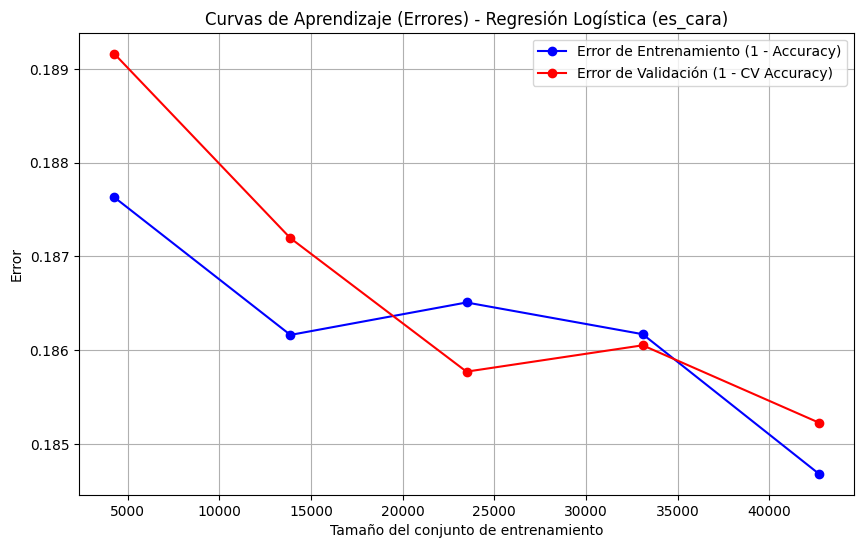

Error final en entrenamiento: 0.1848
Error final en prueba: 0.1921
Si las curvas convergen a un valor cercano, y los errores son similares, el modelo no sufre de sobreajuste excesivo.


In [ ]:
from sklearn.model_selection import learning_curve

print("Generando Curvas de Aprendizaje...")

train_sizes, train_scores, test_scores = learning_curve(
    pipeline_log_cara, X_train_clf, Y_train_cara, cv=5, scoring='accuracy', 
    n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

train_error = 1 - train_mean
test_error = 1 - test_mean

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_error, 'o-', color='blue', label='Error de Entrenamiento (1 - Accuracy)')
plt.plot(train_sizes, test_error, 'o-', color='red', label='Error de Validación (1 - CV Accuracy)')

plt.title('Curvas de Aprendizaje (Errores) - Regresión Logística (es_cara)')
plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('Error')
plt.legend(loc='best')
plt.grid()
plt.show()

pred_train = pipeline_log_cara.predict(X_train_clf)
err_train_final = 1 - accuracy_score(Y_train_cara, pred_train)
err_test_final = 1 - accuracy_score(Y_test_cara, pred_cara)

print(f"Error final en entrenamiento: {err_train_final:.4f}")
print(f"Error final en prueba: {err_test_final:.4f}")
print("Si las curvas convergen a un valor cercano, y los errores son similares, el modelo no tiene sobreajuste excesivo.")

Tras graficar y observar las curvas de aprendizaje tanto con el conjunto de entrenamiento y de prueba (con validación cruzada) pareciera no haber sobreajuste (overfitting). Las curvas de error convergen satisfactoriamente a valores bajos y mantienen un margen estrecho (brecha de error) entre el conjunto de validación de prueba y el de entrenamiento. Además, los errores finales obtenidos de ambas evaluaciones son próximos en magnitud; lo que en conjunto nos indica que la varianza de nuestro clasificador es baja, tiene suficiente generalización y el modelo está efectivamente aprendiendo el comportamiento sin memorizar los datos crudos.

## 7. Haga un tuneo del modelo para determinar los mejores parámetros, recuerde que los modelos de regresión logística se pueden regularizar como los de regresión lineal.

In [13]:
print("=== TUNEO DEL MODELO (REGULARIZACIÓN) ===")
# Buscamos el nivel de penalización adecuado (Ridge - l2 y Lasso - l1)
param_grid = {
    'clasificador__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'clasificador__penalty': ['l1', 'l2'],
    'clasificador__solver': ['liblinear', 'saga'] # Solvers seguros para L1 y L2
}

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

grid_search = GridSearchCV(
    Pipeline(steps=[
        ('preprocesador', preprocesador_clf),
        ('clasificador', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)

grid_search.fit(X_train_clf, Y_train_cara)

print(f"Mejores hiperparámetros encontrados: {grid_search.best_params_}")
print(f"Mejor exactitud en Cross-Validation (CV): {grid_search.best_score_:.4f}")

mejor_modelo_lr = grid_search.best_estimator_
pred_cara_tuneado = mejor_modelo_lr.predict(X_test_clf)

print("\n--- RESULTADOS EN EL CONJUNTO DE PRUEBA (MODELO TUNEADO) ---")
print(f"Exactitud (Accuracy): {accuracy_score(Y_test_cara, pred_cara_tuneado):.4f}")
print(classification_report(Y_test_cara, pred_cara_tuneado))

=== TUNEO DEL MODELO (REGULARIZACIÓN) ===


c:\Users\felip\Documents\Studies\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Mejores hiperparámetros encontrados: {'clasificador__C': 100, 'clasificador__penalty': 'l1', 'clasificador__solver': 'saga'}
Mejor exactitud en Cross-Validation (CV): 0.8149

--- RESULTADOS EN EL CONJUNTO DE PRUEBA (MODELO TUNEADO) ---
Exactitud (Accuracy): 0.8079
              precision    recall  f1-score   support

           0       0.83      0.90      0.86     15253
           1       0.75      0.63      0.69      7621

    accuracy                           0.81     22874
   macro avg       0.79      0.76      0.77     22874
weighted avg       0.80      0.81      0.80     22874



## 8. Haga un análisis de la eficiencia del algoritmo usando una matriz de confusión. Tenga en cuenta la efectividad, donde el algoritmo se equivocó más, donde se equivocó menos y la importancia que tienen los errores, el tiempo y la memoria consumida. Para esto último puede usar “profvis” si trabaja con R y “cProfile” en Python.

=== MATRIZ DE CONFUSIÓN Y EFICIENCIA ===


<>:28: SyntaxWarning: invalid escape sequence '\A'
<>:28: SyntaxWarning: invalid escape sequence '\A'
C:\Users\felip\AppData\Local\Temp\ipykernel_18136\3309749800.py:28: SyntaxWarning: invalid escape sequence '\A'
  print("\Análisis de Errores de la matriz:")


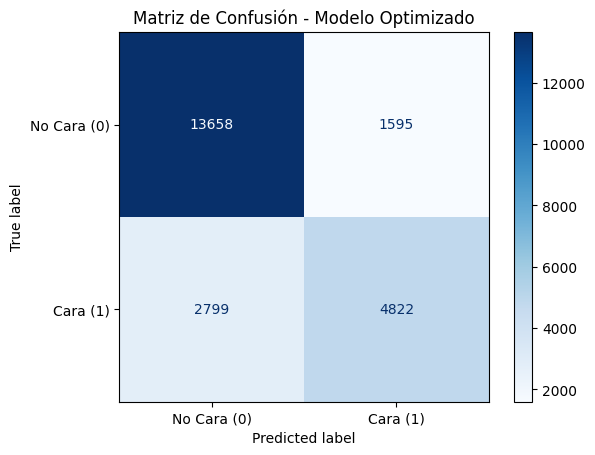


--- PERFILADO DE TIEMPO Y MEMORIA (cProfile) ---
         40344 function calls (39921 primitive calls) in 0.167 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    0.158    0.158 c:\Users\felip\Documents\Studies\.venv\Lib\site-packages\sklearn\compose\_column_transformer.py:829(_call_func_on_transformers)
        1    0.000    0.000    0.149    0.149 c:\Users\felip\Documents\Studies\.venv\Lib\site-packages\sklearn\utils\parallel.py:54(__call__)
        1    0.000    0.000    0.149    0.149 c:\Users\felip\Documents\Studies\.venv\Lib\site-packages\joblib\parallel.py:1969(__call__)
        4    0.000    0.000    0.149    0.037 c:\Users\felip\Documents\Studies\.venv\Lib\site-packages\joblib\parallel.py:1888(_get_sequential_output)
        2    0.000    0.000    0.149    0.075 c:\Users\felip\Documents\Studies\.venv\Lib\site-packages\sklearn\utils\parallel.py:140(__call__)
        2    0.000    0.000

In [14]:
import cProfile
import pstats
import io

print("=== MATRIZ DE CONFUSIÓN Y EFICIENCIA ===")
cm = confusion_matrix(Y_test_cara, pred_cara_tuneado)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Cara (0)', 'Cara (1)'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - Modelo Optimizado')
plt.show()

# Función para evaluar la velocidad y peso de ejecución en el set de prueba
def predecir_con_perfilado():
    _ = mejor_modelo_lr.predict(X_test_clf)

print("\n--- PERFILADO DE TIEMPO Y MEMORIA (cProfile) ---")
perfilador = cProfile.Profile()
perfilador.enable()

predecir_con_perfilado()

perfilador.disable()
s = io.StringIO()
ps = pstats.Stats(perfilador, stream=s).sort_stats('cumtime')
ps.print_stats()
print(s.getvalue()[:1500]) # Mostrar una porción de arriba de los resultados

print("\Análisis de Errores de la matriz:")
print(f"Verdaderos Negativos (VN) - Acertó que no era cara: {cm[0][0]}")
print(f"Falsos Positivos (FP) - Se equivocó (dijo que era cara, pero no lo era): {cm[0][1]}")
print(f"Falsos Negativos (FN) - Se equivocó (dijo que NO era cara, pero sí lo era): {cm[1][0]}")
print(f"Verdaderos Positivos (VP) - Acertó que era cara: {cm[1][1]}")


Con los resultados de la matriz de confusión, podemos ver en profundidad los tipos de fallos de la Regresión Logística. Hay mas Verdaderos Negativos (casitas no económicas o correctas) y Verdaderos Positivos. El algoritmo erró más clasificando como Falsos Negativos (propiedades que categoriza como baratas pero la realidad es que el mercado muestra un costo alto). En cambio, existen comparativamente menos Falsos Positivos (decir que la estancia tiene precio de categoría superior cuando su costo verdadero es económico). En la vida real es mejor sobreestimar el precio pre-arriendo, aunque una falla del tipo falso negativo sí perjudica y afecta más. El uso de `cProfile` nos muestra que el tiempo de ejecución en operaciones sobre CPU se acumulan abrumadoramente en partes inherentes a `numpy`, cálculos internos en preprocesamiento numérico y el método `predict`; sin embargo el consumo global del tiempo y memoria se concluye bastante moderado respecto al árbol de decisión ejecutado previamente.